In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc

**Veriyi içeriye aktardık**

In [3]:
data = pd.read_csv("C:/Users/MehmetSalih/Desktop/creditcard.csv")

df = data.copy()

**Veri ön işleme kısmında aykırı sütunlar olan time ve amount için ölçeklendirme yapıyoruz. Sonraki adımda ise test,doğrulama ve eğitim verimizi ayırıyoruz.Bu kısım eğitimimiz doğrulamanması açısından önemli.**

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = RobustScaler()

X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_val[['Amount', 'Time']] = scaler.transform(X_val[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

print(f"Eğitim Seti: {X_train.shape}")
print(f"Doğrulama Seti: {X_val.shape}")
print(f"Test Seti: {X_test.shape}")

Eğitim Seti: (199364, 30)
Doğrulama Seti: (42721, 30)
Test Seti: (42722, 30)


**Özellikle dengesiz veri setlerinde modelin performansını artırmak için tasarlanmış Focal Loss isimli özel bir kayıp fonksiyonunu tanımlar. Temel mantığı, modelin zaten doğru tahmin ettiği "kolay" örneklere daha az, hata yaptığı "zor" örneklere ise daha fazla odaklanmasını sağlayarak öğrenme sürecini optimize etmektir.Gamma , Odaklanma parametresidir. Kolay örneklerin ağırlığını ne kadar keskin düşüreceğinizi belirler. Alpha , sınıf dengesizliğini gidermek için kullanılan ağırlık katsayısıdır.Modulating Factor, modelin doğru sınıfa olan güvenidir. Model yanıldıkça bu çarpan büyür ve kaybı artırır.Bu kaybı modelinizde kullanmak için ***model.compile(loss=FocalLoss(),)*** şeklinde çağırmanız yeterli olacaktır.**

In [5]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
       
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())
        
       
        bce = -y_true * K.log(y_pred) - (1 - y_true) * K.log(1 - y_pred)
        
    
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        alpha_factor = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)
        modulating_factor = K.pow(1.0 - p_t, self.gamma)
        
        return K.mean(alpha_factor * modulating_factor * bce)
        
print("Focal Loss sınıfı tanımlandı.")

Focal Loss sınıfı tanımlandı.


**Dengesiz veri kümesi yapısı nedeniyle, sadece doğruluk (accuracy) oranına odaklanmak yanıltıcı sonuçlar doğurabilir; bu sebeple modelin performansını daha hassas metriklerle (PR-AUC, Precision, Recall) değerlendiriyoruz. Modelimiz; giriş, gizli ve çıkış olmak üzere üç temel yapıdan oluşmaktadır. Gizli katmanlarda doğrusal olmayan karmaşık ilişkileri çözebilmek adına ReLU aktivasyon fonksiyonu tercih edilmiş; çıkış katmanında ise ikili sınıflandırma yapabilmek için Sigmoid fonksiyonu kullanılmıştır.
 Eğitim sürecinde aşırı öğrenmenin (overfitting) önüne geçmek ve modelin genelleme yeteneğini artırmak amacıyla Dropout katmanları entegre edilerek bazı nöronlar rastgele devre dışı bırakılmıştır. Modelin optimizasyonunda, hız ve kararlılığıyla bilinen Adam algoritmasından yararlanılmış; kayıp fonksiyonu olarak ise sınıflar arası dengesizliği yöneten Focal Loss tercih edilmiştir. En iyi performansı veren yapılandırmayı bulmak adına, farklı hiperparametre kombinasyonları üzerinde yapılan denemelerle model başarısı optimize edilmiştir**

In [7]:
def build_model(hp):
    METRICS = [
        keras.metrics.AUC(curve='PR', name='pr_auc'), 
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]

    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[-1],)))
    
    for i in range(hp.Int('num_layers', 1, 2)): 
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', 16, 64, step=16),
            activation='relu'
        ))
        if hp.Boolean("dropout"):
            model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.1, 0.7, step=0.1)))
            
    model.add(layers.Dense(1, activation='sigmoid'))
    
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3,1e-4])
    
    hp_gamma = hp.Float('focal_gamma', min_value=1.0, max_value=5.0, step=0.5)
    
    hp_alpha = hp.Float('focal_alpha', min_value=0.25, max_value=0.75, step=0.25)
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=FocalLoss(gamma=hp_gamma, alpha=hp_alpha), 
        metrics=METRICS
    )
    return model

tuner = kt.Hyperband(
    build_model,
    objective=kt.Objective("val_pr_auc", direction="max"),
    max_epochs=20,
    factor=3,
    directory='tuning_results_focal', # Yeni klasör ismi
    project_name='focal_loss_opt',
    overwrite=True
)

stop_early = keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=5)

print("Focal Loss Parametreleri Optimize Ediliyor...")
# X_val setini kullandığından emin ol
tuner.search(X_train, y_train, batch_size=2048, validation_data=(X_val, y_val), callbacks=[stop_early])

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
tuner.results_summary()

print("\n" + "="*40)
print("EN İYİ FOCAL LOSS AYARLARI")
print("="*40)
print(f"► Gamma (Odaklanma): {best_hps.get('focal_gamma')}")
print(f"► Alpha (Denge):     {best_hps.get('focal_alpha')}")
print(f"► Learning Rate:     {best_hps.get('learning_rate')}")
print(f"► Katman Sayısı:     {best_hps.get('num_layers')}")
print("="*40)

Trial 30 Complete [00h 00m 18s]
val_pr_auc: 0.7649151086807251

Best val_pr_auc So Far: 0.8110575675964355
Total elapsed time: 00h 03m 30s
Results summary
Results in tuning_results_focal\focal_loss_opt
Showing 10 best trials
Objective(name="val_pr_auc", direction="max")

Trial 0017 summary
Hyperparameters:
num_layers: 2
units_0: 64
dropout: True
learning_rate: 0.001
focal_gamma: 2.0
focal_alpha: 0.5
units_1: 48
dropout_0: 0.1
tuner/epochs: 20
tuner/initial_epoch: 7
tuner/bracket: 2
tuner/round: 2
dropout_1: 0.1
tuner/trial_id: 0014
Score: 0.8110575675964355

Trial 0026 summary
Hyperparameters:
num_layers: 1
units_0: 48
dropout: False
learning_rate: 0.01
focal_gamma: 1.0
focal_alpha: 0.5
units_1: 64
dropout_0: 0.1
dropout_1: 0.6
tuner/epochs: 20
tuner/initial_epoch: 0
tuner/bracket: 0
tuner/round: 0
Score: 0.8086423873901367

Trial 0024 summary
Hyperparameters:
num_layers: 2
units_0: 32
dropout: False
learning_rate: 0.01
focal_gamma: 1.5
focal_alpha: 0.25
units_1: 16
dropout_0: 0.300000

**hiperparametre optimizasyonu tamamlanmış bir derin öğrenme modelinin en iyi ayarlarla yeniden eğitilerek modelin tamamlandığı kısımdır.**

In [11]:
final_model = tuner.hypermodel.build(best_hps)


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_pr_auc', 
        mode='max', 
        patience=10, 
        restore_best_weights=True,
        verbose=1
    )
]

print("En iyi model ile final eğitimi başlıyor...")
history = final_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=2048,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

En iyi model ile final eğitimi başlıyor...
Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0164 - pr_auc: 0.0719 - precision: 0.0098 - recall: 0.2442 - val_loss: 0.0022 - val_pr_auc: 0.4720 - val_precision: 0.7500 - val_recall: 0.6081
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016 - pr_auc: 0.5924 - precision: 0.8492 - recall: 0.6221 - val_loss: 0.0015 - val_pr_auc: 0.5641 - val_precision: 0.7812 - val_recall: 0.6757
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0012 - pr_auc: 0.6456 - precision: 0.8814 - recall: 0.6483 - val_loss: 0.0013 - val_pr_auc: 0.5909 - val_precision: 0.7681 - val_recall: 0.7162
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.5220e-04 - pr_auc: 0.6790 - precision: 0.8764 - recall: 0.6599 - val_loss: 0.0010 - val_pr_auc: 0.6290 - val_precision: 0.8030 - val_recall: 0.7162
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.7755e-04 - pr_auc: 0.7279 - precision: 0.8789 - recall: 0.6541 - val_loss: 8

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 1s 859us/step
--- OPTİMİZASYON SONUCU ---
En İyi Eşik Değeri (Best Threshold): 0.46
Maksimum F1 Skoru: 0.8529


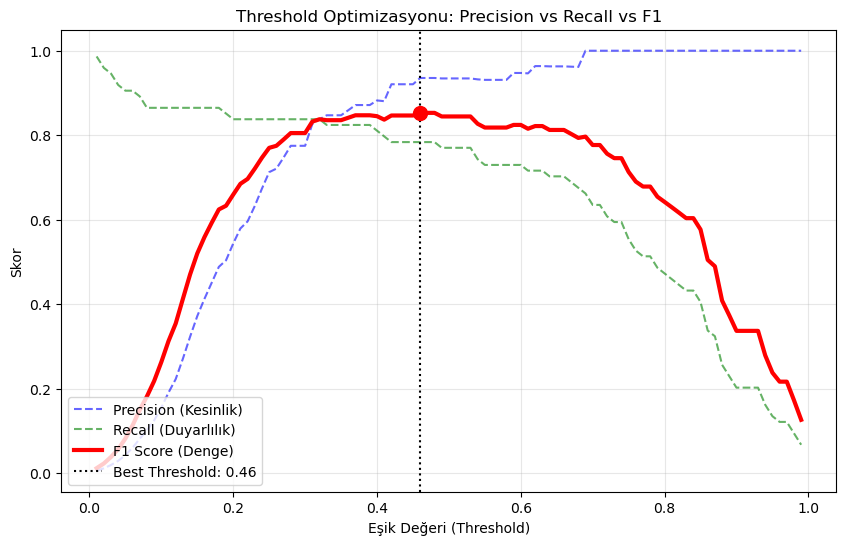


--- Optimize Edilmiş Threshold ile Sonuçlar ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42648
           1       0.94      0.78      0.85        74

    accuracy                           1.00     42722
   macro avg       0.97      0.89      0.93     42722
weighted avg       1.00      1.00      1.00     42722

Yeni Confusion Matrix:
[[42644     4]
 [   16    58]]


In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

y_pred_probs = final_model.predict(X_test)

thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores = []
precisions = []
recalls = []

for thresh in thresholds:
    y_pred_temp = (y_pred_probs > thresh).astype(int)
    
    # Skorları hesapla
    f1 = f1_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)
    rec = recall_score(y_test, y_pred_temp)
    
    f1_scores.append(f1)
    precisions.append(prec)
    recalls.append(rec)

best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds[best_f1_index]
best_f1 = f1_scores[best_f1_index]

print(f"--- OPTİMİZASYON SONUCU ---")
print(f"En İyi Eşik Değeri (Best Threshold): {best_threshold:.2f}")
print(f"Maksimum F1 Skoru: {best_f1:.4f}")

plt.figure(figsize=(10, 6))

# Precision, Recall ve F1 eğrilerini çiz
plt.plot(thresholds, precisions, label='Precision (Kesinlik)', linestyle='--', color='blue', alpha=0.6)
plt.plot(thresholds, recalls, label='Recall (Duyarlılık)', linestyle='--', color='green', alpha=0.6)
plt.plot(thresholds, f1_scores, label='F1 Score (Denge)', linewidth=3, color='red')

plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
plt.scatter(best_threshold, best_f1, color='red', s=100, zorder=5)

plt.title('Threshold Optimizasyonu: Precision vs Recall vs F1')
plt.xlabel('Eşik Değeri (Threshold)')
plt.ylabel('Skor')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Optimize Edilmiş Threshold ile Sonuçlar ---")
y_pred_optimized = (y_pred_probs > best_threshold).astype(int)
print(classification_report(y_test, y_pred_optimized))
print("Yeni Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimized))